# LightGBM

LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework developed by Microsoft.

It is designed to train gradient boosting decision tree models efficiently on large datasets.

LightGBM is especially known for:

- High training speed
- Low memory usage
- Good predictive performance
- Efficient handling of large datasets
- Leaf-wise tree growth
- Histogram-based learning
- Gradient-based One-Side Sampling (GOSS)
- Exclusive Feature Bundling (EFB)

LightGBM can be used for:

- Classification
- Regression
- Ranking
- Large-scale machine learning problems

## Why LightGBM?

Traditional Gradient Boosting builds trees sequentially.

At each iteration:

1. Calculate the errors of the current model.
2. Train a new tree to predict those errors.
3. Add the new tree to the ensemble.
4. Repeat the process.

Although this works well, training can become expensive for large datasets.

LightGBM introduces several optimizations to make gradient boosting faster and more memory efficient.

The main ideas are:

- Histogram-based split finding
- Leaf-wise tree growth
- Gradient-based One-Side Sampling
- Exclusive Feature Bundling
- Efficient categorical feature handling

## Gradient Boosting Foundation

Suppose the training dataset contains:

$$
D = \{(x_i, y_i)\}_{i=1}^{n}
$$

Gradient boosting builds an additive model:

$$
F(x) = \sum_{m=1}^{M} \eta h_m(x)
$$

where:

- $M$ = number of boosting iterations
- $\eta$ = learning rate
- $h_m(x)$ = decision tree added at iteration $m$

At each iteration, a new tree is trained to reduce the current model's loss.

The general objective is:

$$
\min_F \sum_{i=1}^{n} L(y_i, F(x_i))
$$

## LightGBM vs Traditional Gradient Boosting

Traditional gradient boosting often uses level-wise tree growth.

LightGBM uses leaf-wise tree growth.

### Level-wise growth

The tree grows one complete level at a time.

Example:

```text
        Root
       /    \
      A      B
     / \    / \
    C   D  E   F

All nodes at the same depth are expanded together.

### Leaf-wise growth

LightGBM chooses the leaf that provides the largest reduction in loss and splits that leaf.

Example:

```text
        Root
       /    \
      A      B
     / \
    C   D
       / \
      E   F

The tree is not necessarily balanced.


---


## Leaf-Wise Tree Growth

The key idea of LightGBM is:

> Split the leaf that gives the largest reduction in the objective function.

Suppose several leaves are available:

$$
\{L_1, L_2, L_3, L_4\}
$$

and their potential loss reductions are:

$$
\Delta L_1 = 5
$$

$$
\Delta L_2 = 12
$$

$$
\Delta L_3 = 7
$$

$$
\Delta L_4 = 3
$$

LightGBM chooses $L_2$ because it produces the largest reduction in loss.

This can make LightGBM more accurate with fewer splits.

However, unrestricted leaf-wise growth can also overfit, especially on small datasets.

Important parameters for controlling this include:

- `num_leaves`
- `max_depth`
- `min_child_samples`
- `min_split_gain`

## Level-Wise vs Leaf-Wise Growth

| Property | Level-Wise | Leaf-Wise |
|---|---|---|
| Tree growth | Level by level | Best leaf first |
| Tree shape | More balanced | Potentially asymmetric |
| Training speed | Usually slower | Usually faster |
| Accuracy | Good | Often better |
| Overfitting risk | Lower | Higher |
| Main control | Depth | Number of leaves |

LightGBM's leaf-wise strategy is one of its major differences from many traditional boosting implementations.

## Histogram-Based Learning

Finding the best split can be expensive when every unique feature value is considered.

LightGBM reduces this cost using histogram-based learning.

Instead of evaluating every unique continuous value, feature values are grouped into bins.

For example:

```text
Original values:

1.02
1.15
1.31
2.05
2.21
2.89
3.14
3.72

These values can be converted into bins:

```text
Bin 1: 1.0 - 1.5
Bin 2: 2.0 - 2.5
Bin 3: 2.5 - 3.0
Bin 4: 3.0 - 4.0

The algorithm then searches for good splits using these bins.

```text
This reduces:

Computation
Memory usage
Number of candidate split points


---


## Histogram-Based Learning Intuition

Suppose a feature contains:

$$
x = [1.1, 1.2, 1.3, 2.1, 2.2, 2.9, 3.1, 3.2]
$$

Instead of considering every unique value, LightGBM can place them into discrete bins.

For example:

$$
Bin(x) =
\begin{cases}
0 & 1.0 \leq x < 2.0 \\
1 & 2.0 \leq x < 3.0 \\
2 & 3.0 \leq x
\end{cases}
$$

The split search can then operate on these bins.

The parameter controlling the approximate number of bins is:

```python
max_bin


---


## Gradient-Based One-Side Sampling (GOSS)

GOSS stands for:

**Gradient-based One-Side Sampling**

During boosting, training examples have different gradient magnitudes.

A large gradient generally means that the current model is making a larger error for that observation.

GOSS keeps:

- Observations with large gradients
- A sample of observations with small gradients

The intuition is:

> Keep the difficult examples while reducing the number of easy examples used during training.

This can reduce computation while preserving useful information for finding good splits.

## Exclusive Feature Bundling (EFB)

EFB stands for:

**Exclusive Feature Bundling**

High-dimensional datasets can contain many sparse features.

For example, one-hot encoded features may look like:

```text
Feature A  Feature B  Feature C  Feature D
1          0          0          0
0          1          0          0
0          0          1          0
0          0          0          1

Many of these features are mutually exclusive.

LightGBM can bundle mutually exclusive sparse features together.

This reduces the effective number of features and therefore improves computational efficiency.

EFB is particularly useful for high-dimensional sparse datasets.


---


## Important LightGBM Hyperparameters

Some important parameters are:

### Number of trees

```python
n_estimators

### Learning rate

```python
learning_rate
```
Controls the contribution of each tree.

Smaller values generally require more trees.    

### Number of leaves
```python
num_leaves

Controls the maximum number of leaves in a tree.

This is one of the most important LightGBM parameters.

Larger values:

```text
Increase model complexity
Can improve training performance
Can increase overfitting risk

### Maximum depth
```python
max_depth
```

Limits the maximum depth of the tree.

Controls the minimum number of samples required in a leaf.

Larger values generally make the model more conservative.


---


## More Important Hyperparameters

### Feature sampling

```python
colsample_bytree

Controls the fraction of features considered for each tree.

### Row sampling
```python
subsample
```
Controls the fraction of training observations used.

### Regularization
```python
reg_alpha
reg_lambda
```
These control L1 and L2 regularization.

### Minimum split gain
```python
min_split_gain
```
Specifies the minimum gain required to perform a split.

### Maximum bins
```python
max_bin
```

Controls the number of bins used by histogram-based learning.

### Random seed
```python
random_state
```
Controls reproducibility.


---


## The Relationship Between `num_leaves` and `max_depth`

For a binary tree with maximum depth $d$, the theoretical maximum number of leaves is:

$$
2^d
$$

For example:

$$
d = 3
$$

gives:

$$
2^3 = 8
$$

possible leaves.

However, LightGBM's leaf-wise growth does not necessarily produce a balanced tree.

Therefore, `num_leaves` is often a more direct control over model complexity.

A useful practical principle is:

$$
num\_leaves \lesssim 2^{max\_depth}
$$

when both parameters are being used together.

This is a heuristic rather than a strict requirement.

## Installing LightGBM

If LightGBM is not already installed:

```python
%pip install lightgbm

In [25]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



---


# LightGBM Classification

We will first use LightGBM for a binary classification problem.

The workflow will be:

1. Load the dataset
2. Split into training and testing sets
3. Create the LightGBM classifier
4. Train the model
5. Make predictions
6. Evaluate the model
7. Analyze feature importance

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

In [27]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [28]:
X.shape

(569, 30)

In [29]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

## Train-Test Split

We split the dataset into:

- Training data
- Testing data

The model learns from the training set and is evaluated on unseen test data.

For classification, we use stratification so that the class distribution is approximately preserved.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (455, 30)
Testing shape: (114, 30)


## Creating a LightGBM Classifier

We can create a LightGBM classifier using:

```python
LGBMClassifier()

Example parameters:

n_estimators=200
learning_rate=0.05
num_leaves=31
max_depth=-1

Here:

n_estimators controls the number of boosting iterations.
learning_rate controls the contribution of each tree.
num_leaves controls tree complexity.
max_depth=-1 means no explicit maximum depth.

In [31]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    verbosity=-1
)

model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [32]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9649122807017544
Precision: 0.9594594594594594
Recall   : 0.9861111111111112
F1 Score : 0.9726027397260274
ROC-AUC  : 0.9897486772486772


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## Confusion Matrix

A confusion matrix shows:

- True Positives
- True Negatives
- False Positives
- False Negatives

It helps us understand the types of classification errors made by the model.

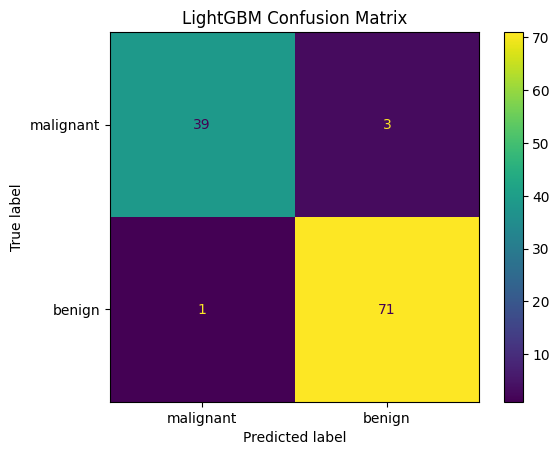

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("LightGBM Confusion Matrix")
plt.show()

# Feature Importance

LightGBM provides feature importance information.

Two common importance types are:

### Split importance

Measures how often a feature is used to split trees.

### Gain importance

Measures the contribution of a feature to reducing the objective.

Gain-based importance is often more informative when we want to understand how much a feature contributes to model improvement.

In [36]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
21,worst texture,507
27,worst concave points,498
28,worst symmetry,283
22,worst perimeter,255
7,mean concave points,238
1,mean texture,235
13,area error,227
20,worst radius,206
24,worst smoothness,182
23,worst area,174


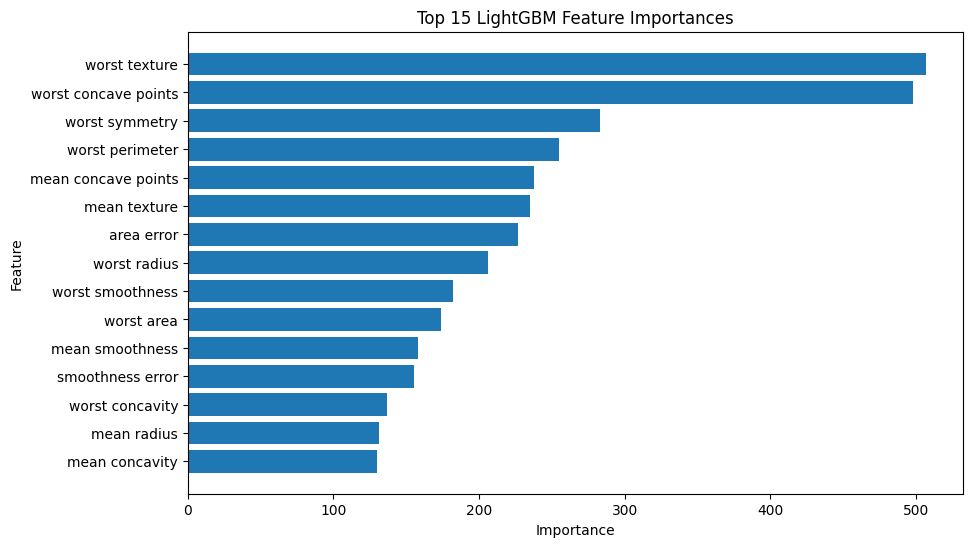

In [37]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 LightGBM Feature Importances")

plt.show()

# Early Stopping

A large number of trees does not always improve generalization.

Early stopping monitors validation performance during training.

If validation performance stops improving for a specified number of iterations, training can stop.

For example:

```python
callbacks=[
    early_stopping(30)
]

This means that training can stop when there has been no improvement for 30 rounds.

Early stopping can:

Reduce unnecessary computation
Help prevent overfitting
Automatically determine a useful number of boosting iterations

In [38]:
from lightgbm import early_stopping

In [39]:
model_es = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

model_es.fit(
    X_train,
    y_train,
    eval_X=X_test,
    eval_y=y_test,
    callbacks=[
        early_stopping(30)
    ]
)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[135]	valid_0's binary_logloss: 0.111688


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [40]:
print("Best iteration:", model_es.best_iteration_)

Best iteration: 135


In [41]:
y_pred_es = model_es.predict(X_test)

accuracy_es = accuracy_score(
    y_test,
    y_pred_es
)

print("Accuracy:", accuracy_es)

Accuracy: 0.9649122807017544


## Important Note About Early Stopping

The test set should ideally not be used as the early-stopping validation set when the goal is to obtain an unbiased final test estimate.

A better workflow is:

```text
Training data
      |
      +---- Training subset
      |
      +---- Validation subset
                       |
                 Early stopping

Final test set
      |
   Used only once
   for final evaluation

For rigorous model evaluation, create a separate validation set or use cross-validation


---


# LightGBM Regression

LightGBM can also solve regression problems.

For regression, the model predicts a continuous target.

Examples:

- House prices
- Sales
- Demand
- Temperature
- Revenue
- Delivery time

In [42]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

In [43]:
data_reg = load_diabetes()

X_reg = pd.DataFrame(
    data_reg.data,
    columns=data_reg.feature_names
)

y_reg = pd.Series(
    data_reg.target,
    name="target"
)

X_reg.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [44]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [45]:
reg_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

reg_model.fit(
    X_train_reg,
    y_train_reg
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [46]:
y_pred_reg = reg_model.predict(X_test_reg)

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²   :", r2)

MAE : 44.38486079156973
RMSE: 55.45441618204413
R²   : 0.41957263210659035


# LightGBM Categorical Features

One useful LightGBM capability is native handling of categorical features.

For example:

```text
City
----
Delhi
Mumbai
Kolkata
Delhi
Mumbai

Instead of necessarily applying one-hot encoding manually, LightGBM can work with categorical features when they are correctly represented as categorical data.

Example:

```python
X["City"] = X["City"].astype("category")

Then the feature can be supplied to LightGBM as a categorical feature.

This can be particularly useful for datasets containing many categorical variables.


---

# Controlling Overfitting in LightGBM

LightGBM can overfit because leaf-wise tree growth is highly flexible.

Important controls include:

### 1. Reduce `num_leaves`

```python
num_leaves=15

Fewer leaves reduce tree complexity.

### 2. Increase min_child_samples
```python
min_child_samples=30
```

This requires more observations in each leaf.

### 3. Limit max_depth
```python
max_depth=6
```

### 4. Reduce learning rate
```python
learning_rate=0.02
```
and increase the number of trees appropriately.

### 5. Use regularization
```python
reg_alpha
reg_lambda
```
### 6. Use feature sampling
```python
colsample_bytree
```
### 7. Use row sampling
subsample

### 8. Use early stopping

Stop training when validation performance stops improving.


---

## A Practical LightGBM Complexity Strategy

Instead of immediately using a very large model, start conservatively.

For example:

```python
model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=30,
    reg_lambda=1.0,
    random_state=42
)

Then use early stopping with a validation set.

The general principle is:

$$ \text{Model Complexity} \uparrow \Rightarrow \text{Overfitting Risk} \uparrow $$

and

Learning Rate↓⇒More Trees Usually Needed


---


# LightGBM vs XGBoost

Both LightGBM and XGBoost are powerful gradient boosting frameworks.

| Feature | LightGBM | XGBoost |
|---|---|---|
| Algorithm | Gradient Boosting Trees | Gradient Boosting Trees |
| Tree growth | Leaf-wise | Usually depth-wise / level-wise |
| Histogram learning | Yes | Yes |
| Training speed | Very fast | Very fast |
| Memory efficiency | Excellent | Excellent |
| Large datasets | Excellent | Excellent |
| Overfitting risk | Higher with aggressive leaf growth | Generally easier to control |
| Categorical handling | Strong native support | Traditionally requires more preprocessing |
| Sparse data | Excellent | Excellent |
| Common use | Large-scale tabular ML | General tabular ML |

There is no universal winner.

Performance depends on:

- Dataset
- Feature engineering
- Hyperparameters
- Validation strategy
- Computational constraints

### XGBoost

In its common tree-building configuration, tree growth is more level/depth oriented.

Therefore:

LightGBM → aggressive leaf-wise growth
XGBoost  → more depth/level-oriented growth

This is a useful distinction when studying the two algorithms.


---


# End-to-End LightGBM Workflow

A practical LightGBM workflow looks like:

```text
Raw Dataset
     |
     ↓
Data Cleaning
     |
     ↓
Train / Validation / Test Split
     |
     ↓
Feature Preparation
     |
     ↓
LightGBM Model
     |
     ↓
Hyperparameter Tuning
     |
     ↓
Early Stopping
     |
     ↓
Final Evaluation
     |
     ↓
Feature Importance
     |
     ↓
Model Deployment


---


# Advantages of LightGBM

### 1. Very Fast Training

Histogram-based learning significantly reduces split-search computation.

### 2. Memory Efficient

Feature binning and other optimizations reduce memory usage.

### 3. Excellent Performance

LightGBM often achieves strong predictive performance on tabular datasets.

### 4. Scales Well

It is designed for large datasets.

### 5. Leaf-Wise Growth

Choosing the best leaf for splitting can produce highly effective trees.

### 6. Handles Large Feature Spaces

EFB can improve efficiency for high-dimensional sparse datasets.

### 7. Supports Categorical Features

LightGBM provides native categorical feature support.

### 8. Supports Multiple Objectives

It supports:

- Classification
- Regression
- Ranking
- Other specialized objectives

# Disadvantages of LightGBM

### 1. Can Overfit Easily

Leaf-wise growth can create very complex trees.

### 2. Hyperparameter Sensitive

Parameters such as:

- `num_leaves`
- `learning_rate`
- `min_child_samples`
- `max_depth`

can strongly affect performance.

### 3. Small Datasets

On very small datasets, LightGBM may overfit more easily than simpler models.

### 4. Less Interpretable

An ensemble of many trees is harder to interpret than a single decision tree.

### 5. Parameter Interactions

Changing one hyperparameter can affect how other parameters should be configured.

### 6. Requires Careful Validation

Because the model is powerful, poor validation can produce overly optimistic results.

# When Should You Use LightGBM?

LightGBM is especially useful when:

- The dataset is tabular
- The dataset is large
- There are many features
- Training speed matters
- Predictive performance matters
- Nonlinear relationships are present
- Feature interactions are important

Common applications include:

- Fraud detection
- Customer churn prediction
- Credit risk
- Ranking systems
- Recommendation systems
- Demand forecasting
- Search ranking
- Financial prediction
- Classification of large tabular datasets

# When LightGBM May Not Be the Best Choice

LightGBM may not be ideal when:

- The dataset is extremely small
- A highly interpretable model is required
- The problem is fundamentally image-based
- The problem is fundamentally raw-text based
- A simpler model already performs sufficiently well
- The data contains complex sequential structure better handled by specialized models

For image, audio, and raw natural-language problems, deep learning architectures are often more appropriate.

For small tabular datasets, simpler models such as logistic regression, linear regression, or a regularized tree model may be preferable depending on the problem.

# Important LightGBM Concepts to Remember

### LightGBM

A fast gradient boosting framework based primarily on decision trees.

### Leaf-wise growth

Splits the leaf with the highest potential gain.

### Histogram-based learning

Groups continuous values into bins to speed up split finding.

### GOSS

Keeps important high-gradient observations and samples low-gradient observations.

### EFB

Bundles mutually exclusive sparse features.

### `num_leaves`

Controls the number of leaves and therefore strongly affects model complexity.

### `learning_rate`

Controls how strongly each tree contributes to the ensemble.

### `n_estimators`

Controls the maximum number of boosting iterations.

### Early stopping

Stops training when validation performance stops improving.

### Regularization

Helps control model complexity and overfitting.

# Mathematical View of Gradient Boosting

At iteration $m$, suppose the current model is:

$$
F_{m-1}(x)
$$

For each training example, calculate the negative gradient:

$$
g_i =
-
\left[
\frac{\partial L(y_i, F(x_i))}
{\partial F(x_i)}
\right]_{F=F_{m-1}}
$$

A new tree $h_m(x)$ is then fitted to approximate these gradients.

The model is updated as:

$$
F_m(x)
=
F_{m-1}(x)
+
\eta h_m(x)
$$

where:

$$
\eta
$$

is the learning rate.

The process continues for multiple boosting iterations.

This is the fundamental idea behind gradient boosting and therefore forms the mathematical foundation of LightGBM.

# A More Conservative LightGBM Model

A practical starting configuration can be:

```python
model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=6,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

This is not a universally optimal configuration.

Hyperparameters should be selected using validation data or cross-validation.

The goal is to control model complexity while allowing enough boosting iterations for the smaller learning rate.


---

# Comparison of Ensemble Algorithms

## Cell 57 — Markdown

```markdown
# Ensemble Learning Comparison

| Algorithm | Main Idea | Tree Growth | Main Strength |
|---|---|---|---|
| Bagging | Train independent models | Independent | Variance reduction |
| Random Forest | Bagging + random features | Independent | Robustness |
| AdaBoost | Focus on misclassified samples | Sequential | Simple boosting |
| Gradient Boosting | Fit trees to gradients | Sequential | Strong predictive power |
| XGBoost | Optimized gradient boosting | Depth/level-oriented | Performance + regularization |
| LightGBM | Optimized gradient boosting | Leaf-wise | Speed + scalability |

A useful conceptual progression is:

```text
Bagging
   ↓
Random Forest
   ↓
Boosting
   ↓
Gradient Boosting
   ↓
XGBoost
   ↓
LightGBM


---


# Summary

LightGBM is a highly optimized gradient boosting framework.

The most important ideas are:

1. LightGBM builds an ensemble of decision trees sequentially.
2. It uses gradient boosting to minimize a loss function.
3. It uses histogram-based learning for efficient split finding.
4. It uses leaf-wise tree growth.
5. Leaf-wise growth can provide strong predictive performance but can also increase overfitting.
6. `num_leaves` is a particularly important complexity parameter.
7. GOSS reduces the number of training observations considered.
8. EFB reduces the effective dimensionality of sparse feature spaces.
9. Learning rate and number of trees should be considered together.
10. Early stopping can reduce unnecessary boosting iterations.
11. Regularization and tree constraints help control overfitting.
12. LightGBM is especially strong for large-scale tabular machine learning.

The core idea to remember is:

$$
\boxed{
\text{LightGBM}
=
\text{Gradient Boosting}
+
\text{Efficient Histograms}
+
\text{Leaf-Wise Growth}
+
\text{Sampling/Feature Optimizations}
}
$$